In [23]:
%reset -f

In [24]:
%%bash

wget -nc -q --show-progress https://raw.githubusercontent.com/fvicini/RBM_ML_2026/c47fccb4c3aa8e204239c3a7b5057d9deba46920/other_utilities.py

if [ ! -d "Meshes" ]; then
  git init temp_repo -q && cd temp_repo
  git remote add origin https://github.com/fvicini/RBM_ML_2026.git
  git config core.sparseCheckout true
  echo "Meshes/*" >> .git/info/sparse-checkout
  git fetch --depth 1 origin c47fccb4c3aa8e204239c3a7b5057d9deba46920 -q
  git checkout FETCH_HEAD -q
  mv Meshes ../
  cd .. && rm -rf temp_repo
fi

# **Navier-Stokes: POD vs POD-NN**
## Model Order Reduction and Machine Learning
### Matteo Salicandro, Matteo Tedde

In [25]:
import numpy as np
import argparse
import os.path
import scipy.sparse
import vtk
from pypolydim import polydim, gedim
from pypolydim.export_vtk_utilities import ExportVTKUtilities
from pypolydim.assembler_utilities import assembler_utilities
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import time

np.random.seed(67)

import sys
sys.path.insert(1, '../')
import other_utilities as other_ut

In [26]:
geometry_utilities_config = gedim.GeometryUtilitiesConfig()
geometry_utilities_config.tolerance1_d = 1.0e-6
geometry_utilities_config.tolerance2_d = 1.0e-12
geometry_utilities = gedim.GeometryUtilities(geometry_utilities_config)
mesh_utilities = gedim.MeshUtilities()
vtk_utilities = ExportVTKUtilities()

In [27]:
# Export folder
export_file_path = "./Export/Test_1"
if not os.path.exists(export_file_path):
    os.makedirs(export_file_path)

# Mesh file path
export_mesh_path = export_file_path + "/Mesh"
if not os.path.exists(export_mesh_path):
    os.makedirs(export_mesh_path)

# Solution file path
export_solution_path = export_file_path + "/Solution"
if not os.path.exists(export_solution_path):
    os.makedirs(export_solution_path)

In [28]:
pde_domain = polydim.pde_tools.mesh.pde_mesh_utilities.PDE_Domain_2D()
pde_domain.vertices = np.array([[0.0, 1.0, 1.0, 0.0],
                                [0.0, 0.0, 1.0, 1.0],
                                [0.0, 0.0, 0.0, 0.0]])
pde_domain.shape_type = polydim.pde_tools.mesh.pde_mesh_utilities.PDE_Domain_2D.Domain_Shape_Types.parallelogram
pde_domain.area = 1.0

In [29]:
mesh_type = polydim.pde_tools.mesh.pde_mesh_utilities.MeshGenerator_Types_2D.triangular
method_type = polydim.pde_tools.local_space_pcc_2_d.MethodTypes.fem_pcc
mesh_size = 0.001

In [30]:
mesh_data = gedim.MeshMatrices()
mesh = gedim.MeshMatricesDAO(mesh_data)

polydim.pde_tools.mesh.pde_mesh_utilities.create_mesh_2_d(geometry_utilities,
                                                          mesh_utilities,
                                                          mesh_type,
                                                          pde_domain,
                                                          mesh_size,
                                                          mesh)
mesh_geometric_data = polydim.pde_tools.mesh.pde_mesh_utilities.compute_mesh_2_d_geometry_data(geometry_utilities, mesh_utilities, mesh)

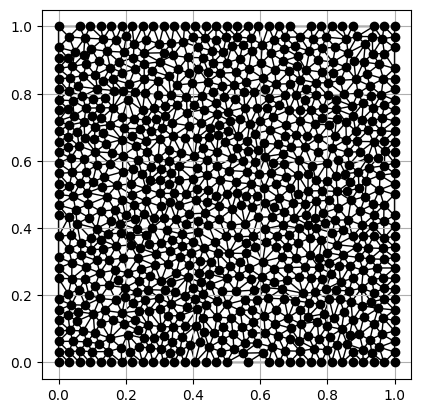

In [31]:
vtk_utilities.export_mesh(export_mesh_path, mesh)
other_ut.plot_mesh(mesh)

In [32]:
info_internal = polydim.pde_tools.do_fs.DOFsManager.MeshDOFsInfo.BoundaryInfo(polydim.pde_tools.do_fs.DOFsManager.MeshDOFsInfo.BoundaryInfo.BoundaryTypes.none)
info_internal.marker = 0

info_dirichlet = polydim.pde_tools.do_fs.DOFsManager.MeshDOFsInfo.BoundaryInfo(polydim.pde_tools.do_fs.DOFsManager.MeshDOFsInfo.BoundaryInfo.BoundaryTypes.strong)
info_dirichlet.marker = 1

info_neumann_none = polydim.pde_tools.do_fs.DOFsManager.MeshDOFsInfo.BoundaryInfo(polydim.pde_tools.do_fs.DOFsManager.MeshDOFsInfo.BoundaryInfo.BoundaryTypes.none)
info_neumann_none.marker = 0

pressure_boundary_info = {
    0: info_internal,
    1: info_dirichlet,
    2: info_neumann_none,
    3: info_neumann_none,
    4: info_neumann_none,
    5: info_neumann_none,
    6: info_neumann_none,
    7: info_neumann_none,
    8: info_neumann_none
}

speed_boundary_info = {
    0: info_internal,
    1: info_dirichlet,
    2: info_dirichlet,
    3: info_dirichlet,
    4: info_dirichlet,
    5: info_dirichlet,
    6: info_dirichlet,
    7: info_dirichlet,
    8: info_dirichlet
}

In [33]:
mesh_connectivity_data = polydim.pde_tools.mesh.MeshMatricesDAO_mesh_connectivity_data(mesh)

pressure_reference_element_data = polydim.pde_tools.local_space_pcc_2_d.create_reference_element(method_type,
                                                                                              1)
speed_reference_element_data = polydim.pde_tools.local_space_pcc_2_d.create_reference_element(method_type,
                                                                                             2)

dof_manager = polydim.pde_tools.do_fs.DOFsManager()

pressure_mesh_dofs_info = polydim.pde_tools.local_space_pcc_2_d.set_mesh_do_fs_info(pressure_reference_element_data,
                                                                                    mesh,
                                                                                    pressure_boundary_info)
pressure_dofs_data = dof_manager.create_do_fs_2_d(pressure_mesh_dofs_info,
                                                  mesh_connectivity_data)

speed_mesh_dofs_info = polydim.pde_tools.local_space_pcc_2_d.set_mesh_do_fs_info(speed_reference_element_data,
                                                                                 mesh,
                                                                                 speed_boundary_info)
speed_dofs_data = dof_manager.create_do_fs_2_d(speed_mesh_dofs_info,
                                               mesh_connectivity_data)

In [34]:
pressure_n_dofs = pressure_dofs_data.number_do_fs
pressure_n_strongs = pressure_dofs_data.number_strongs
speed_n_dofs = speed_dofs_data.number_do_fs
speed_n_strongs = speed_dofs_data.number_strongs
tot_dofs = 2 * speed_n_dofs + pressure_n_dofs
tot_strongs = 2 * speed_n_strongs + pressure_n_strongs

In [35]:
print("P dofs\t", "P stgs\t", "U dofs\t", "U stgs\t", "T dofs\t", "T stgs")
print(pressure_n_dofs,"\t", pressure_n_strongs,"\t", speed_n_dofs,"\t", speed_n_strongs,"\t", tot_dofs,"\t", tot_strongs)

P dofs	 P stgs	 U dofs	 U stgs	 T dofs	 T stgs
829 	 1 	 2966 	 234 	 6761 	 469


In [36]:
mu = 0.1
mu1 = 1

def pressure_exact(x, y, z):
    return 0.0

def pressure_exact_gradient(x, y, z):
    return np.array([0.0,0.0,0.0])

def speed_x_exact(x, y, z):
    return 0.0

def speed_y_exact(x, y, z):
    return 0.0

def speed_x_exact_laplacian(x, y, z):
    return 0.0

def speed_y_exact_laplacian(x, y, z):
    return 0.0


In [37]:
def generate_snapshot(snapshot_num):
  mu_range = [0.1, 10.]
  mu1_range = [1., 3.]
  P = np.array([mu_range, mu1_range])
  training_set = np.random.uniform(low=P[:, 0], high=P[:, 1], size=(snapshot_num, P.shape[0]))

  return training_set
generate_snapshot(10)

array([[5.50392916, 2.71771322],
       [6.89033661, 1.66318364],
       [0.6939795 , 1.77255556],
       [2.2101836 , 2.8650133 ],
       [7.25590116, 1.09379061],
       [8.23097741, 2.183739  ],
       [2.59550793, 1.63015338],
       [1.95959642, 1.70063981],
       [2.64670384, 1.02222823],
       [4.15492625, 1.8245089 ]])

In [38]:
def f_x_function(x, y, z):
    return -(mu1**3*np.pi**2*np.cos(mu1**2*np.pi*x)-mu1**2*np.pi**2)*np.sin(mu1*np.pi*y)*np.cos(mu1*np.pi*y) + (mu1*np.pi*np.cos(mu1*np.pi*x)*np.cos(mu1*np.pi*y))


def f_y_function(x, y, z):
    return -(-mu1**3 * (np.pi)**2 * np.cos(mu1**2 * np.pi * y) + mu1**2 * np.pi ** 2) * np.sin(mu1 * np.pi * x) * np.cos(mu1 * np.pi * x) + (-mu1 * np.pi * np.sin(mu1 * np.pi * x) * np.sin(mu1 * np.pi * y))

f_x = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_source_term(geometry_utilities,
                                                                       mesh,
                                                                       mesh_geometric_data,
                                                                       speed_dofs_data,
                                                                       speed_reference_element_data,
                                                                       speed_reference_element_data,
                                                                       f_x_function)
f_y = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_source_term(geometry_utilities,
                                                                       mesh,
                                                                       mesh_geometric_data,
                                                                       speed_dofs_data,
                                                                       speed_reference_element_data,
                                                                       speed_reference_element_data,
                                                                       f_y_function)

f_S = np.concatenate([f_x, f_y, np.zeros(pressure_n_dofs)])

In [39]:
def pressure_strong_function(marker, x, y, z):
    if marker==1:
      return 0.0 #vertice basso-sinistra
    else:
      return None

p_strong = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_strong_solution(geometry_utilities,
                                                                       mesh,
                                                                       mesh_geometric_data,
                                                                       pressure_mesh_dofs_info,
                                                                       pressure_dofs_data,
                                                                       pressure_reference_element_data,
                                                                       pressure_strong_function)

In [40]:
def speed_x_strong_function(marker, x, y, z):
    return 0.0 #tutto il bordo
def speed_y_strong_function(marker, x, y, z):
    return 0.0 #tutto il bordo

u_x_strong = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_strong_solution(geometry_utilities,
                                                                       mesh,
                                                                       mesh_geometric_data,
                                                                       speed_mesh_dofs_info,
                                                                       speed_dofs_data,
                                                                       speed_reference_element_data,
                                                                       speed_x_strong_function)
u_y_strong = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_strong_solution(geometry_utilities,
                                                                       mesh,
                                                                       mesh_geometric_data,
                                                                       speed_mesh_dofs_info,
                                                                       speed_dofs_data,
                                                                       speed_reference_element_data,
                                                                       speed_y_strong_function)

In [41]:
def mu_term(x, y, z):
    return mu
def b_x_term(x, y, z):
    return np.array([\
        1.0,\
        0.0,\
        0.0])
def b_y_term(x, y, z):
    return np.array([\
        0.0,\
        1.0,\
        0.0])

A_operator = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_diffusion_operator(geometry_utilities,
                                                                                       mesh,
                                                                                       mesh_geometric_data,
                                                                                       speed_dofs_data,
                                                                                       speed_dofs_data,
                                                                                       speed_reference_element_data,
                                                                                       speed_reference_element_data,
                                                                                       mu_term)


J_A_x = other_ut.make_np_sparse(A_operator.operator_dofs, [tot_dofs, tot_dofs], [0, 0])
J_A_y = other_ut.make_np_sparse(A_operator.operator_dofs, [tot_dofs, tot_dofs], [speed_n_dofs, speed_n_dofs])

B_x_operator = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_advection_operator(geometry_utilities,
                                                                       mesh,
                                                                       mesh_geometric_data,
                                                                       speed_dofs_data,
                                                                       pressure_dofs_data,
                                                                       speed_reference_element_data,
                                                                       pressure_reference_element_data,
                                                                       b_x_term)
B_y_operator = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_advection_operator(geometry_utilities,
                                                                       mesh,
                                                                       mesh_geometric_data,
                                                                       speed_dofs_data,
                                                                       pressure_dofs_data,
                                                                       speed_reference_element_data,
                                                                       pressure_reference_element_data,
                                                                       b_y_term)

J_B_x = other_ut.make_np_sparse(B_x_operator.operator_dofs, [tot_dofs, tot_dofs], [2 * speed_n_dofs, 0])
J_B_y = other_ut.make_np_sparse(B_y_operator.operator_dofs, [tot_dofs, tot_dofs], [2 * speed_n_dofs, speed_n_dofs])
J_BT_x = other_ut.make_np_sparse(B_x_operator.operator_dofs, [tot_dofs, tot_dofs], [2 * speed_n_dofs, 0], True)
J_BT_y = other_ut.make_np_sparse(B_y_operator.operator_dofs, [tot_dofs, tot_dofs], [2 * speed_n_dofs, speed_n_dofs], True)


J_S = J_A_x + J_A_y - J_B_x - J_B_y - J_BT_x - J_BT_y

In [42]:
def speed_x_initial_condition(x, y, z):
    return 0.0
def speed_y_initial_condition(x, y, z):
    return 0.0
def pressure_initial_condition(x, y, z):
    return 0.0

u_x_numeric = polydim.pde_tools.assembler_utilities.pcc_2_d.evaluate_function_on_dofs(geometry_utilities,
                                                                                mesh,
                                                                                mesh_geometric_data,
                                                                                speed_dofs_data,
                                                                                speed_reference_element_data,
                                                                                speed_x_initial_condition).function_dofs
u_y_numeric = polydim.pde_tools.assembler_utilities.pcc_2_d.evaluate_function_on_dofs(geometry_utilities,
                                                                                mesh,
                                                                                mesh_geometric_data,
                                                                                speed_dofs_data,
                                                                                speed_reference_element_data,
                                                                                speed_y_initial_condition).function_dofs
p_numeric = polydim.pde_tools.assembler_utilities.pcc_2_d.evaluate_function_on_dofs(geometry_utilities,
                                                                                mesh,
                                                                                mesh_geometric_data,
                                                                                pressure_dofs_data,
                                                                                pressure_reference_element_data,
                                                                                pressure_initial_condition).function_dofs

u_k = np.concatenate([u_x_numeric, u_y_numeric, p_numeric])
du_x_strong = np.zeros(speed_n_strongs)
du_y_strong = np.zeros(speed_n_strongs)
dp_strong = np.zeros(pressure_n_strongs)
residual_norm = 1.0
solution_norm = 1.0
newton_tol = 1.0e-6
max_iterations = 10
num_iteration = 1

In [43]:
while num_iteration < max_iterations and residual_norm > newton_tol * solution_norm:
    c_operator = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_ns_operators(geometry_utilities,
                                                                                     mesh,
                                                                                     mesh_geometric_data,
                                                                                     speed_dofs_data,
                                                                                     speed_reference_element_data,
                                                                                     u_x_numeric,
                                                                                     u_y_numeric,
                                                                                     u_x_strong,
                                                                                     u_y_strong)

    J_C = other_ut.make_np_sparse(c_operator.convective_operator.operator_dofs, [tot_dofs, tot_dofs], [0, 0])
    f_C = np.concatenate([c_operator.convective_rhs, np.zeros(pressure_n_dofs)])

    J_f = f_S - f_C - J_S @ u_k
    du = scipy.sparse.linalg.spsolve(J_S + J_C, J_f)

    u_k = u_k + du

    du_x = du[0:speed_n_dofs]
    du_y = du[speed_n_dofs:2 * speed_n_dofs]
    dp = du[2 * speed_n_dofs:]

    u_x_numeric = u_k[0:speed_n_dofs]
    u_y_numeric = u_k[speed_n_dofs:2 * speed_n_dofs]
    p_numeric = u_k[2 * speed_n_dofs:]

    du_x_error_L2 = polydim.pde_tools.assembler_utilities.pcc_2_d.compute_error_l2(geometry_utilities,
                                                                                 mesh,
                                                                                 mesh_geometric_data,
                                                                                 speed_dofs_data,
                                                                                 speed_reference_element_data,
                                                                                 du_x,
                                                                                 du_x_strong)
    du_y_error_L2 = polydim.pde_tools.assembler_utilities.pcc_2_d.compute_error_l2(geometry_utilities,
                                                                                 mesh,
                                                                                 mesh_geometric_data,
                                                                                 speed_dofs_data,
                                                                                 speed_reference_element_data,
                                                                                 du_y,
                                                                                 du_y_strong)
    dp_error_L2 = polydim.pde_tools.assembler_utilities.pcc_2_d.compute_error_l2(geometry_utilities,
                                                                                 mesh,
                                                                                 mesh_geometric_data,
                                                                                 pressure_dofs_data,
                                                                                 pressure_reference_element_data,
                                                                                 dp,
                                                                                 dp_strong)
    u_x_error_L2 = polydim.pde_tools.assembler_utilities.pcc_2_d.compute_error_l2(geometry_utilities,
                                                                                mesh,
                                                                                mesh_geometric_data,
                                                                                speed_dofs_data,
                                                                                speed_reference_element_data,
                                                                                u_x_numeric,
                                                                                u_x_strong,
                                                                                speed_x_exact)
    u_y_error_L2 = polydim.pde_tools.assembler_utilities.pcc_2_d.compute_error_l2(geometry_utilities,
                                                                                mesh,
                                                                                mesh_geometric_data,
                                                                                speed_dofs_data,
                                                                                speed_reference_element_data,
                                                                                u_y_numeric,
                                                                                u_y_strong,
                                                                                speed_y_exact)
    p_error_L2 = polydim.pde_tools.assembler_utilities.pcc_2_d.compute_error_l2(geometry_utilities,
                                                                                mesh,
                                                                                mesh_geometric_data,
                                                                                pressure_dofs_data,
                                                                                pressure_reference_element_data,
                                                                                p_numeric,
                                                                                p_strong,
                                                                                pressure_exact)

    solution_norm = np.sqrt(u_x_error_L2.numeric_norm_l2 * u_x_error_L2.numeric_norm_l2 +
                           u_y_error_L2.numeric_norm_l2 * u_y_error_L2.numeric_norm_l2 +
                           p_error_L2.numeric_norm_l2 * p_error_L2.numeric_norm_l2);
    residual_norm = np.sqrt(du_x_error_L2.numeric_norm_l2 * du_x_error_L2.numeric_norm_l2 +
                           du_y_error_L2.numeric_norm_l2 * du_y_error_L2.numeric_norm_l2 +
                           dp_error_L2.numeric_norm_l2 * dp_error_L2.numeric_norm_l2);

    print(f"{u_k.shape}")
    print("dofs", "u_x_errorL2", "u_y_errorL2", "p_errorL2", "residual", "iteration", "max_iteration")
    print(tot_dofs, '{:.2e}'.format(u_x_error_L2.error_l2 / u_x_error_L2.numeric_norm_l2), '{:.2e}'.format(u_y_error_L2.error_l2 / u_y_error_L2.numeric_norm_l2), '{:.2e}'.format(p_error_L2.error_l2 / p_error_L2.numeric_norm_l2), '{:.16e}'.format(residual_norm / solution_norm), '{:d}'.format(num_iteration), '{:d}'.format(max_iterations))

    num_iteration = num_iteration + 1

(6761,)
dofs u_x_errorL2 u_y_errorL2 p_errorL2 residual iteration max_iteration
6761 1.00e+00 1.00e+00 1.00e+00 1.0000000000000000e+00 1 10
(6761,)
dofs u_x_errorL2 u_y_errorL2 p_errorL2 residual iteration max_iteration
6761 1.00e+00 1.00e+00 1.00e+00 4.6111274616301118e-01 2 10
(6761,)
dofs u_x_errorL2 u_y_errorL2 p_errorL2 residual iteration max_iteration
6761 1.00e+00 1.00e+00 1.00e+00 3.8753353895376288e-04 3 10
(6761,)
dofs u_x_errorL2 u_y_errorL2 p_errorL2 residual iteration max_iteration
6761 1.00e+00 1.00e+00 1.00e+00 1.6146327643956193e-09 4 10


In [44]:
u_x_error_L2 = polydim.pde_tools.assembler_utilities.pcc_2_d.compute_error_l2(geometry_utilities,
                                                                                mesh,
                                                                                mesh_geometric_data,
                                                                                speed_dofs_data,
                                                                                speed_reference_element_data,
                                                                                u_x_numeric,
                                                                                u_x_strong,
                                                                                speed_x_exact)
print("dofs", "errorL2")
print(speed_dofs_data.number_do_fs, '{:.2e}'.format(u_x_error_L2.error_l2 / u_x_error_L2.numeric_norm_l2))

dofs errorL2
2966 1.00e+00


In [45]:
u_y_error_L2 = polydim.pde_tools.assembler_utilities.pcc_2_d.compute_error_l2(geometry_utilities,
                                                                                mesh,
                                                                                mesh_geometric_data,
                                                                                speed_dofs_data,
                                                                                speed_reference_element_data,
                                                                                u_y_numeric,
                                                                                u_y_strong,
                                                                                speed_y_exact)
print("dofs", "errorL2")
print(speed_dofs_data.number_do_fs, '{:.2e}'.format(u_y_error_L2.error_l2 / u_y_error_L2.numeric_norm_l2))

dofs errorL2
2966 1.00e+00


In [46]:
p_error_L2 = polydim.pde_tools.assembler_utilities.pcc_2_d.compute_error_l2(geometry_utilities,
                                                                                mesh,
                                                                                mesh_geometric_data,
                                                                                pressure_dofs_data,
                                                                                pressure_reference_element_data,
                                                                                p_numeric,
                                                                                p_strong,
                                                                                pressure_exact)
print("dofs", "errorL2")
print(pressure_dofs_data.number_do_fs, '{:.2e}'.format(p_error_L2.error_l2 / p_error_L2.numeric_norm_l2))

dofs errorL2
829 1.00e+00


In [47]:
u_x_on_cell0Ds = polydim.pde_tools.assembler_utilities.pcc_2_d.extract_solution_on_cell0_ds(mesh,
                                                                       speed_dofs_data,
                                                                                         u_x_numeric,
                                                                                         u_x_strong,
                                                                       speed_x_exact)
u_y_on_cell0Ds = polydim.pde_tools.assembler_utilities.pcc_2_d.extract_solution_on_cell0_ds(mesh,
                                                                       speed_dofs_data,
                                                                                         u_y_numeric,
                                                                                         u_y_strong,
                                                                       speed_y_exact)
p_on_cell0Ds = polydim.pde_tools.assembler_utilities.pcc_2_d.extract_solution_on_cell0_ds(mesh,
                                                                       pressure_dofs_data,
                                                                                         p_numeric,
                                                                                         p_strong,
                                                                       pressure_exact)

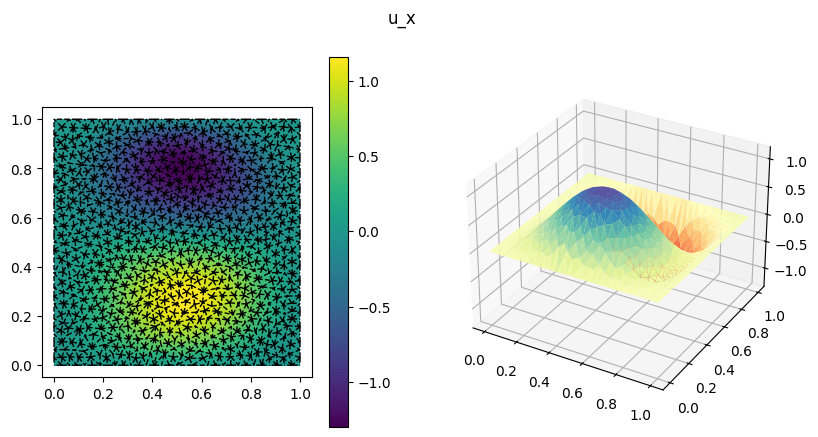

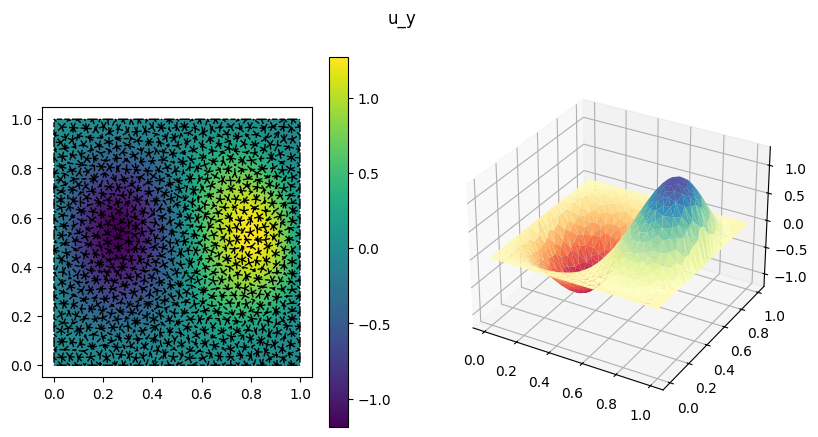

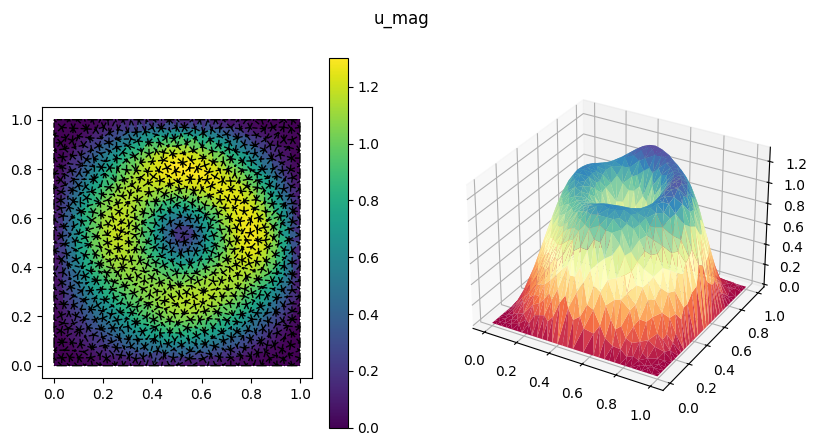

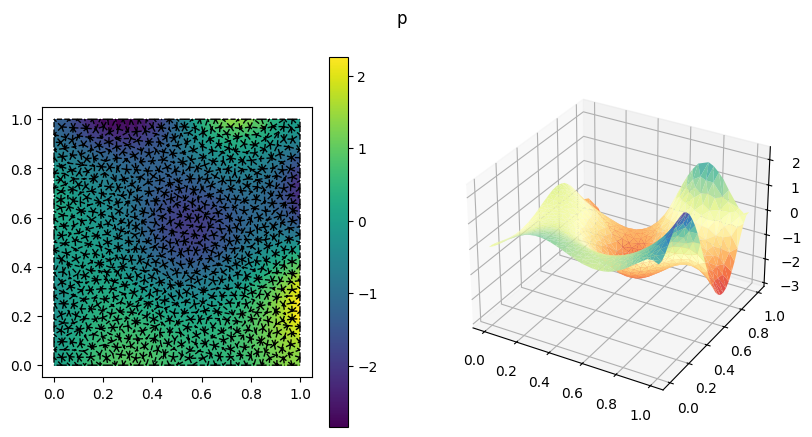

In [48]:
vtk_utilities.export_solution_2(export_solution_path + '/u_x',
                                mesh,
                                u_x_on_cell0Ds.numeric_solution,
                                u_x_on_cell0Ds.exact_solution,
                                u_x_error_L2.cell2_ds_error_l2,
                               u_x_error_L2.cell2_ds_error_l2)
vtk_utilities.export_solution_2(export_solution_path + '/u_y',
                                mesh,
                                u_y_on_cell0Ds.numeric_solution,
                                u_y_on_cell0Ds.exact_solution,
                                u_y_error_L2.cell2_ds_error_l2,
                               u_y_error_L2.cell2_ds_error_l2)
vtk_utilities.export_solution_2(export_solution_path + '/p',
                                mesh,
                                p_on_cell0Ds.numeric_solution,
                                p_on_cell0Ds.exact_solution,
                                p_error_L2.cell2_ds_error_l2,
                               p_error_L2.cell2_ds_error_l2)
other_ut.plot_solution(mesh, u_x_on_cell0Ds.numeric_solution, "u_x")
other_ut.plot_solution(mesh, u_y_on_cell0Ds.numeric_solution, "u_y")
other_ut.plot_solution(mesh, np.sqrt(u_x_on_cell0Ds.numeric_solution * u_x_on_cell0Ds.numeric_solution + u_y_on_cell0Ds.numeric_solution * u_y_on_cell0Ds.numeric_solution), "u_mag")
other_ut.plot_solution(mesh, p_on_cell0Ds.numeric_solution, "p")